# Ensemble model — stacking CatBoost + LogReg + RandomForest, tuned for F2

**Author:** SF — **Status:** final. Same file, same generalized/pooled split as
`sf-LogRegbaseline.ipynb` and `sf-catboost-model.ipynb`. Follows the same three
instructions as the CatBoost notebook — tune for F2, try to beat the baseline, and
document what tuning approach was best — applied to a stacked ensemble.

**This is a rewrite of an earlier version of this notebook**, per the project owner's
direction, with three changes:

1. **CatBoost is tuned once, directly for its role in the ensemble** — not for its own
   standalone F2 (that objective lives in `sf-catboost-model.ipynb`). An earlier version
   of this notebook built two ensembles (one per objective) and compared them; that
   comparison found the difference between the two wasn't a clear win either way, so
   there is no reason to keep carrying both — this version keeps only the
   ensemble-role-tuned CatBoost, as the one and only ensemble in this notebook.
2. **Every hyperparameter search in this notebook uses one search strategy — Bayesian
   (Optuna, TPE sampler) — not a three-way Grid/Random/Bayesian comparison.** See the
   intro's decision log, point 4, for why Bayesian and why dropping the comparison is
   justified rather than arbitrary.
3. **Any claim that one model's metric beats another's is backed by a paired hypothesis
   test on `final_holdout`** (§8), not just a point-estimate table. Point estimates
   alone can't distinguish "genuinely better" from "this holdout happened to land this
   way" — the tests in §8 quantify that directly.

**A further, smaller round of changes, per the project owner's follow-up:** (a) §7.1 now
shows a dedicated F2-only train/validation/holdout table contrasting the *not-tuned*
(@0.5) and *tuned* ensemble side by side, not just buried inside the two AUC+F2 stage
tables; (b) §8's hypothesis-test matrix is expanded from 2 comparisons to 5 — it now also
tests the not-tuned ensemble against the LogReg baseline, against standalone CatBoost at
its own untuned (@0.5) state, and against the *tuned* ensemble itself (does tuning the
threshold produce a real F2 gain, or could it be noise?); (c) every plotted figure in this
notebook now shows F2 only — AUC is still reported in tables where it adds useful context,
but no longer plotted, to keep the visual story focused on the one metric this notebook is
actually optimizing for.

## Scope

Same generalized (pooled) split as both prior notebooks — all 6 use cases pooled, split
at the row level, `final_holdout` bit-for-bit identical across all three notebooks. Not a
Leave-One-Use-Case-Out test.

## Decisions made before writing any modelling code

Confirmed with the project owner rather than assumed:

1. **Ensemble method: stacking with a meta-learner**, not voting/averaging. Each base
   model produces out-of-fold predictions on `train_pool` (never predicting on rows it
   was trained on); a meta-learner is trained on those out-of-fold predictions to learn
   how to combine them — chosen over plain voting because it can learn a non-uniform,
   data-driven combination rather than assuming every base model deserves equal trust.
2. **Three base models: CatBoost, the LogReg baseline, and `RandomForestClassifier`.**
   All three see the **identical `PCA(50)`+features space** as `sf-catboost-model.ipynb`,
   so the ensemble is combining differences in model *inductive bias*, not differences in
   what information each model can see. CatBoost's hyperparameters are tuned specifically
   for its contribution to the ensemble (§4) — a genuinely different optimization target
   from `sf-catboost-model.ipynb`'s own standalone-F2 tuning, and not assumed in advance
   to have the same answer (it didn't, quite — see §4's own numbers).
3. **Meta-learner: `LogisticRegression`** — simple, interpretable (its 3 coefficients
   show how much the ensemble trusts each base model), and low-risk of overfitting the
   combination step itself given only 3 input features.
4. **Search strategy: Bayesian (Optuna/TPE) only, for every hyperparameter search in this
   notebook — RandomForest (§3) and CatBoost (§4) alike.** An earlier version of this
   notebook, and `sf-catboost-model.ipynb`, each ran a full Grid vs. Random vs. Bayesian
   comparison. Both times, the three strategies landed within ~0.001–0.002 of each other
   — at a 24-evaluation budget on this dataset, which strategy wins looks like noise, not
   a real property of one method being better. Bayesian is kept as the one method going
   forward because (a) it won the earlier RF comparison outright, (b) it was already the
   only method used for CatBoost's ensemble-role search, and (c) being adaptive — each
   trial is informed by every previous one — it is the most sample-efficient choice when
   the budget is being spent on one method rather than split three ways.
5. **The classification threshold is tuned for F2** on the meta-learner's own pooled
   out-of-fold predictions on `train_pool`, exactly like `sf-catboost-model.ipynb` — never
   on `final_holdout`.
6. **Comparative claims are backed by a paired bootstrap hypothesis test**, not a bare
   point-estimate table (§8) — see that section for the method and why it was chosen over
   alternatives like McNemar's test.

## Structure

(1) load/split (reproduced verbatim, bit-identical to both prior notebooks); (2) base
model pipelines and metric helpers; (3) `RandomForestClassifier`'s hyperparameter search;
(4) CatBoost's hyperparameter search, tuned for its ensemble role; (5) the hyperparameter
catalog — every tuned value in one place; (6) out-of-fold predictions and meta-learner
tuning; (7) train and test the final ensemble; (8) statistical hypothesis tests against
the baseline and standalone CatBoost; (9) side-by-side comparison table; (10) hard
findings; (11) scope & limitations.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from catboost import CatBoostClassifier
from joblib import Parallel, delayed
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Parameters

Same split/feature-space parameters as both prior notebooks, copied verbatim.
`SEARCH_BUDGET` is the number of Bayesian trials given to *each* of the two searches in
this notebook (RF, CatBoost) — one shared constant, since both now use the same single
search strategy. `CATBOOST_STANDALONE_PARAMS` is `sf-catboost-model.ipynb`'s own winning
configuration, tuned for CatBoost's *standalone* F2 — kept here **only** as an external
reference point for §8's hypothesis tests (“is the ensemble better than that other
notebook's model”), not used anywhere in building this notebook's own ensemble.

In [2]:
DATA_PATH = "../../data/processed/papers_fe.parquet"

TARGET_COL = "triage_label"
POSITIVE_LABEL = "positive"
NEGATIVE_LABELS = ["negative"]

USE_CASE_COL = "use_case_key"
GROUP_COL = "first_author"

# Identical to sf-LogRegbaseline.ipynb / sf-catboost-model.ipynb - see this notebook's intro, decision 2.
NON_EMBEDDING_FEATURE_COLS = [
    "lex_n_tokens", "lex_bm25_obj", "lex_bm25_prob", "lex_bm25_must", "lex_bm25_nice", "lex_bm25_dom",
    "lex_rank_bm25_obj", "lex_rank_bm25_prob", "lex_rank_bm25_must", "lex_rank_bm25_nice", "lex_rank_bm25_dom",
    "lex_overlap_must_n", "lex_overlap_must_frac", "lex_rank_overlap_must",
    "lex_overlap_nice_n", "lex_overlap_nice_frac", "lex_rank_overlap_nice",
    "lex_overlap_excl_n", "lex_overlap_excl_frac",
    "lex_overlap_must_per_1k", "lex_overlap_nice_per_1k", "lex_has_exclude_terms",
    "cos_brief_jasper", "rank_cos_brief_jasper",
    "cos_brief_qwen4b", "rank_cos_brief_qwen4b",
    "cos_brief_qwen8b", "rank_cos_brief_qwen8b",
    "year", "paper_age", "has_abstract", "n_authors", "citation_count",
]

PCA_N_COMPONENTS = 50
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 5
RANDOM_STATE = 0

THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)
CB_THREAD_COUNT = 1
SEARCH_N_JOBS = -1

SEARCH_BUDGET = 24         # Bayesian/Optuna trials, shared by the RF and CatBoost searches
META_C_GRID = {"C": [0.01, 0.03, 0.1, 0.3, 1.0, 10.0]}
N_BOOT = 2000              # bootstrap resamples for §8's hypothesis tests

# sf-catboost-model.ipynb's own winning config (Randomized Search, tuned for standalone F2).
# External reference only - see the note above and §8. Not used in this notebook's ensemble.
CATBOOST_STANDALONE_PARAMS = {
    "depth": 4,
    "iterations": 797,
    "l2_leaf_reg": 40.268379614011366,
    "learning_rate": 0.0589974509393851,
}

## 1. Load, clean, and split — bit-for-bit identical to both prior notebooks

Reproduced verbatim rather than imported, matching this project's self-contained-notebook
convention. The row-count assertion checks this against both prior notebooks' own
reported split, so a silent divergence would fail loudly here instead of quietly
invalidating §8's cross-notebook comparisons.

In [3]:
df = pd.read_parquet(DATA_PATH)
EMBEDDING_COLS = [c for c in df.columns if c.startswith("emb_")]

missing_expected = [c for c in NON_EMBEDDING_FEATURE_COLS if c not in df.columns]
if missing_expected:
    raise ValueError(
        f"Expected non-embedding feature column(s) not found in this file: {missing_expected}. "
        f"The schema has changed since this notebook was built - stop and check before continuing."
    )

df["lex_overlap_excl_n"] = df["lex_overlap_excl_n"].fillna(0.0)
df["lex_overlap_excl_frac"] = df["lex_overlap_excl_frac"].fillna(0.0)

df = df[df[TARGET_COL].isin([POSITIVE_LABEL, *NEGATIVE_LABELS])].copy()
df["y"] = (df[TARGET_COL] == POSITIVE_LABEL).astype(int)
FEATURE_COLS = EMBEDDING_COLS + NON_EMBEDDING_FEATURE_COLS

strat_key_outer = df[USE_CASE_COL].astype(str) + "__" + df["y"].astype(str)
outer_cv = StratifiedGroupKFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)
outer_splits = list(outer_cv.split(df, strat_key_outer, groups=df[GROUP_COL]))
train_pool_idx, final_holdout_idx = outer_splits[0]

train_pool = df.iloc[train_pool_idx].reset_index(drop=True)
final_holdout = df.iloc[final_holdout_idx].reset_index(drop=True)

assert len(train_pool) == 1478 and len(final_holdout) == 370, (
    "Row counts don't match sf-LogRegbaseline.ipynb / sf-catboost-model.ipynb's split "
    "(1,478 / 370) - stop and investigate before continuing."
)
print(f"train_pool: {len(train_pool):,} rows | final_holdout: {len(final_holdout):,} rows "
      f"- matches both prior notebooks' split exactly.")

strat_key_inner = train_pool[USE_CASE_COL].astype(str) + "__" + train_pool["y"].astype(str)
inner_cv = StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
inner_splits = list(inner_cv.split(train_pool, strat_key_inner, groups=train_pool[GROUP_COL]))
print(f"{len(inner_splits)} inner folds built within train_pool")

train_pool: 1,478 rows | final_holdout: 370 rows - matches both prior notebooks' split exactly.


5 inner folds built within train_pool


## 2. The three base model pipelines, and metric/statistics helpers

Same `ColumnTransformer` (embedding → `StandardScaler` → `PCA(50, whiten=True)`;
non-embedding → median `SimpleImputer` → `StandardScaler`) underlies all three, so the
only difference between them is the final classifier. `score()` bundles AUC/AP/Recall/F2
at a given prediction. `f2_at_best_threshold()`/`proba_scorer()` make a search F2-aware.
`make_stage_table()` lays train/validation/holdout out side by side. `paired_bootstrap_test()`
is new — see §8 for what it does and why.

In [4]:
def _build_preprocessor():
    embedding_branch = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=PCA_N_COMPONENTS, whiten=True, random_state=RANDOM_STATE)),
    ])
    non_embedding_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer([
        ("embedding_pca", embedding_branch, EMBEDDING_COLS),
        ("non_embedding", non_embedding_branch, NON_EMBEDDING_FEATURE_COLS),
    ])


def build_logreg_pipeline():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def build_catboost_pipeline(**cb_params):
    clf = CatBoostClassifier(
        auto_class_weights="Balanced",
        boosting_type="Ordered",
        random_state=RANDOM_STATE,
        thread_count=CB_THREAD_COUNT,
        verbose=False,
        allow_writing_files=False,
        **cb_params,
    )
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def build_rf_pipeline(**rf_params):
    clf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, **rf_params)
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def score(y_true, proba_pos, pred):
    return {
        "auc": float(roc_auc_score(y_true, proba_pos)),
        "ap": float(average_precision_score(y_true, proba_pos)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
    }


def f2_at_best_threshold(y_true, proba_pos, thresholds=THRESHOLD_GRID):
    y_true = np.asarray(y_true)
    return max(
        fbeta_score(y_true, (proba_pos >= t).astype(int), beta=2, zero_division=0)
        for t in thresholds
    )


def proba_scorer(estimator, X, y):
    pos_col = list(estimator.classes_).index(1)
    proba = estimator.predict_proba(X)[:, pos_col]
    return f2_at_best_threshold(y, proba)


def make_stage_table(train_metrics, val_df, holdout_metrics, metrics=("auc", "f2")):
    """train -> validation (mean +- std across the 5 inner folds) -> holdout, side by side."""
    return pd.DataFrame({
        "train": {m: train_metrics[m] for m in metrics},
        "validation_mean": {m: val_df[m].mean() for m in metrics},
        "validation_std": {m: val_df[m].std() for m in metrics},
        "holdout": {m: holdout_metrics[m] for m in metrics},
    }).T.round(3)


def paired_bootstrap_test(y_true, proba_a, pred_a, proba_b, pred_b, n_boot=N_BOOT, random_state=0):
    """Paired bootstrap significance test comparing model A against model B on the SAME
    holdout rows. Same resample indices are applied to both models each iteration, so the
    correlation between their predictions on the same rows is preserved (this is what makes
    it a *paired* test, not two independent bootstraps).

    Tests both AUC (threshold-invariant ranking quality) and F2 (at each model's own fixed,
    already-chosen prediction) - `pred_a`/`pred_b` must already reflect each model's own
    real operating threshold, not a threshold refit inside this function.

    p-value: two-sided, via the standard percentile-bootstrap convention - the smaller tail
    proportion (resamples where the sign of the difference flips), doubled and capped at 1.
    """
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    n = len(y_true)

    auc_obs = roc_auc_score(y_true, proba_a) - roc_auc_score(y_true, proba_b)
    f2_obs = (fbeta_score(y_true, pred_a, beta=2, zero_division=0)
              - fbeta_score(y_true, pred_b, beta=2, zero_division=0))

    auc_diffs, f2_diffs = [], []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_b = y_true[idx]
        if len(np.unique(y_b)) < 2:
            continue
        auc_diffs.append(roc_auc_score(y_b, proba_a[idx]) - roc_auc_score(y_b, proba_b[idx]))
        f2_diffs.append(fbeta_score(y_b, pred_a[idx], beta=2, zero_division=0)
                         - fbeta_score(y_b, pred_b[idx], beta=2, zero_division=0))
    auc_diffs, f2_diffs = np.array(auc_diffs), np.array(f2_diffs)

    def _ci_and_p(diffs):
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
        return float(lo), float(hi), float(min(p, 1.0))

    auc_lo, auc_hi, auc_p = _ci_and_p(auc_diffs)
    f2_lo, f2_hi, f2_p = _ci_and_p(f2_diffs)
    return {
        "auc_diff": float(auc_obs), "auc_ci_low": auc_lo, "auc_ci_high": auc_hi, "auc_p_value": auc_p,
        "f2_diff": float(f2_obs), "f2_ci_low": f2_lo, "f2_ci_high": f2_hi, "f2_p_value": f2_p,
    }

## 3. `RandomForestClassifier` — hyperparameter search

Bayesian (Optuna/TPE) only, per the intro's decision 4 — `SEARCH_BUDGET` (24) trials,
same `inner_splits`, same F2-at-best-threshold scoring as every other search in this
project. Search space: `n_estimators`, `max_depth`, `min_samples_leaf` (this repo's own
prior finding is that `RandomForestClassifier` overfits badly at this row count — train
AUC 1.000 under LOGO — so `max_depth`/`min_samples_leaf` specifically target that), and
`max_features`. The 5 fold-level fits per trial are parallelized (`joblib.Parallel`).

In [5]:
def _rf_fit_and_score_fold(params, tr_idx, te_idx):
    pipe = build_rf_pipeline(**params)
    fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
    pipe.fit(fold_train[FEATURE_COLS], fold_train["y"])
    return proba_scorer(pipe, fold_test[FEATURE_COLS], fold_test["y"])


def rf_optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
    }
    fold_scores = Parallel(n_jobs=SEARCH_N_JOBS)(
        delayed(_rf_fit_and_score_fold)(params, tr_idx, te_idx) for tr_idx, te_idx in inner_splits
    )
    return float(np.mean(fold_scores))


t0 = time.time()
rf_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_optuna_objective, n_trials=SEARCH_BUDGET, n_jobs=1, show_progress_bar=False)
rf_search_time_s = time.time() - t0
rf_winning_params = dict(rf_study.best_params)
print(f"RF Bayesian search: {SEARCH_BUDGET} trials, {rf_search_time_s:.0f}s, "
      f"best mean CV F2-at-best-threshold = {rf_study.best_value:.4f}")
print(f"Winning RF params: {rf_winning_params}")

RF Bayesian search: 24 trials, 572s, best mean CV F2-at-best-threshold = 0.9031
Winning RF params: {'n_estimators': 527, 'max_depth': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}


## 4. CatBoost — hyperparameter search, tuned for its role in the ensemble

**This is CatBoost's only tuning step in this notebook** — deliberately not the same
objective as `sf-catboost-model.ipynb`'s own standalone-F2 search. A config that's
slightly worse alone but makes different mistakes from LogReg/RF could help the ensemble
more than a config that's better alone but redundant with what LogReg/RF already capture
— this section searches directly for that, rather than assuming the standalone-best
config is also the ensemble-best one.

**Method.** For a candidate CatBoost configuration: (1) build its out-of-fold predictions
on `train_pool` via `inner_splits`, parallelized across folds; (2) combine with the
**fixed** LogReg/RF out-of-fold predictions (`build_logreg_pipeline()` needs no tuning;
RF uses §3's `rf_winning_params`) — fixed so this search isolates CatBoost's contribution,
not a moving target; (3) for each candidate, also re-search the meta-learner's `C` over
`META_C_GRID` (cheap — a handful of `LogisticRegression` fits per candidate, negligible
next to CatBoost's own fitting cost); (4) score via the best-achievable mean CV
F2-at-threshold across `inner_splits`.

**Bayesian (Optuna/TPE), `SEARCH_BUDGET` (24) trials** — same space/bounds as
`sf-catboost-model.ipynb`'s own search (`depth`, `learning_rate`, `l2_leaf_reg`,
`iterations`), per the intro's decision 4.

In [6]:
def _cb_fit_and_predict_fold(cb_params, tr_idx, te_idx):
    pipe = build_catboost_pipeline(**cb_params)
    fold_train = train_pool.iloc[tr_idx]
    pipe.fit(fold_train[FEATURE_COLS], fold_train["y"])
    pos_col = list(pipe.classes_).index(1)
    proba = pipe.predict_proba(train_pool.iloc[te_idx][FEATURE_COLS])[:, pos_col]
    return te_idx, proba


def build_catboost_oof(cb_params):
    cb_oof = np.full(len(train_pool), np.nan)
    results = Parallel(n_jobs=SEARCH_N_JOBS)(
        delayed(_cb_fit_and_predict_fold)(cb_params, tr_idx, te_idx) for tr_idx, te_idx in inner_splits
    )
    for te_idx, proba in results:
        cb_oof[te_idx] = proba
    assert not np.isnan(cb_oof).any()
    return cb_oof


def build_oof(builder):
    """Same leakage-safe OOF construction as build_catboost_oof, generalized to any
    fixed (already-tuned) pipeline builder - used for LogReg/RF, which don't need a
    per-candidate search inside CatBoost's objective."""
    oof = np.full(len(train_pool), np.nan)
    for tr_idx, te_idx in inner_splits:
        pipe = builder()
        fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
        pipe.fit(fold_train[FEATURE_COLS], fold_train["y"])
        pos_col = list(pipe.classes_).index(1)
        oof[te_idx] = pipe.predict_proba(fold_test[FEATURE_COLS])[:, pos_col]
    assert not np.isnan(oof).any()
    return oof


meta_y = train_pool["y"].to_numpy()
logreg_oof = build_oof(build_logreg_pipeline)
rf_oof = build_oof(lambda: build_rf_pipeline(**rf_winning_params))
print(f"  logreg alone - OOF F2 at its own best threshold: {f2_at_best_threshold(meta_y, logreg_oof):.3f}")
print(f"  rf alone      - OOF F2 at its own best threshold: {f2_at_best_threshold(meta_y, rf_oof):.3f}")


def ensemble_score_for_catboost_params(cb_params):
    """Best achievable ensemble F2-at-threshold for a candidate CatBoost config, re-searching
    the meta-learner's C over META_C_GRID rather than assuming a fixed C applies."""
    cb_oof = build_catboost_oof(cb_params)
    candidate_meta_X = np.column_stack([cb_oof, logreg_oof, rf_oof])

    best_c_score, best_c = -np.inf, None
    for c in META_C_GRID["C"]:
        fold_scores = []
        for tr_idx, te_idx in inner_splits:
            meta = LogisticRegression(C=c, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
            meta.fit(candidate_meta_X[tr_idx], meta_y[tr_idx])
            pos_col = list(meta.classes_).index(1)
            proba = meta.predict_proba(candidate_meta_X[te_idx])[:, pos_col]
            fold_scores.append(f2_at_best_threshold(meta_y[te_idx], proba))
        mean_score = float(np.mean(fold_scores))
        if mean_score > best_c_score:
            best_c_score, best_c = mean_score, c
    return best_c_score, best_c, cb_oof


def catboost_ensemble_objective(trial):
    cb_params = {
        "depth": trial.suggest_int("depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 50, log=True),
        "iterations": trial.suggest_int("iterations", 100, 800),
    }
    score_val, _, _ = ensemble_score_for_catboost_params(cb_params)
    return score_val


t0 = time.time()
cb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cb_study.optimize(catboost_ensemble_objective, n_trials=SEARCH_BUDGET, n_jobs=1, show_progress_bar=False)
cb_search_time_s = time.time() - t0
catboost_winning_params = dict(cb_study.best_params)
print(f"\nCatBoost Bayesian search (ensemble objective): {SEARCH_BUDGET} trials, {cb_search_time_s:.0f}s")
print(f"best mean CV F2-at-best-threshold = {cb_study.best_value:.4f}")
print(f"Winning CatBoost params: {catboost_winning_params}")

catboost_oof = build_catboost_oof(catboost_winning_params)
print(f"  catboost alone - OOF F2 at its own best threshold: {f2_at_best_threshold(meta_y, catboost_oof):.3f}")

  logreg alone - OOF F2 at its own best threshold: 0.903
  rf alone      - OOF F2 at its own best threshold: 0.898



CatBoost Bayesian search (ensemble objective): 24 trials, 6137s
best mean CV F2-at-best-threshold = 0.9101
Winning CatBoost params: {'depth': 6, 'learning_rate': 0.06119889729184578, 'l2_leaf_reg': 7.474245667651606, 'iterations': 656}


  catboost alone - OOF F2 at its own best threshold: 0.902


## 5. Hyperparameter catalog

Every hyperparameter tuned in this notebook, its search space, the strategy used to tune
it, and the final value chosen — one table, so nothing has to be dug out of prose or
re-run to check. `meta_C`/`decision_threshold` are filled in after §6 (they depend on
the base-model OOF predictions built there); this table is re-displayed at the end of §6
complete.

In [7]:
hyperparam_catalog_rows = [
    {"model": "RandomForest", "hyperparameter": "n_estimators", "search_space": "int[100, 800]",
     "strategy": "Bayesian (Optuna/TPE)", "final_value": rf_winning_params["n_estimators"]},
    {"model": "RandomForest", "hyperparameter": "max_depth", "search_space": "int[2, 20]",
     "strategy": "Bayesian (Optuna/TPE)", "final_value": rf_winning_params["max_depth"]},
    {"model": "RandomForest", "hyperparameter": "min_samples_leaf", "search_space": "int[1, 10]",
     "strategy": "Bayesian (Optuna/TPE)", "final_value": rf_winning_params["min_samples_leaf"]},
    {"model": "RandomForest", "hyperparameter": "max_features", "search_space": "{sqrt, log2, 0.3, 0.5}",
     "strategy": "Bayesian (Optuna/TPE)", "final_value": rf_winning_params["max_features"]},
    {"model": "CatBoost", "hyperparameter": "depth", "search_space": "int[3, 7]",
     "strategy": "Bayesian (Optuna/TPE), ensemble objective", "final_value": catboost_winning_params["depth"]},
    {"model": "CatBoost", "hyperparameter": "learning_rate", "search_space": "log-uniform[0.01, 0.3]",
     "strategy": "Bayesian (Optuna/TPE), ensemble objective", "final_value": round(catboost_winning_params["learning_rate"], 4)},
    {"model": "CatBoost", "hyperparameter": "l2_leaf_reg", "search_space": "log-uniform[1, 50]",
     "strategy": "Bayesian (Optuna/TPE), ensemble objective", "final_value": round(catboost_winning_params["l2_leaf_reg"], 3)},
    {"model": "CatBoost", "hyperparameter": "iterations", "search_space": "int[100, 800]",
     "strategy": "Bayesian (Optuna/TPE), ensemble objective", "final_value": catboost_winning_params["iterations"]},
]
hyperparam_catalog = pd.DataFrame(hyperparam_catalog_rows)
display(hyperparam_catalog)

,model,hyperparameter,search_space,strategy,final_value
0,RandomForest,n_estimators,"int[100, 800]",Bayesian (Optuna/TPE),527
1,RandomForest,max_depth,"int[2, 20]",Bayesian (Optuna/TPE),13
2,RandomForest,min_samples_leaf,"int[1, 10]",Bayesian (Optuna/TPE),7
3,RandomForest,max_features,"{sqrt, log2, 0.3, 0.5}",Bayesian (Optuna/TPE),sqrt
4,CatBoost,depth,"int[3, 7]","Bayesian (Optuna/TPE), ensemble objective",6
5,CatBoost,learning_rate,"log-uniform[0.01, 0.3]","Bayesian (Optuna/TPE), ensemble objective",0.0612
6,CatBoost,l2_leaf_reg,"log-uniform[1, 50]","Bayesian (Optuna/TPE), ensemble objective",7.474
7,CatBoost,iterations,"int[100, 800]","Bayesian (Optuna/TPE), ensemble objective",656


## 6. Out-of-fold predictions, meta-learner tuning, and F2 threshold selection

`meta_X` stacks the three base models' out-of-fold predictions — `catboost_oof` from §4
(the ensemble-role-tuned config), `logreg_oof`/`rf_oof` already built in §4 as fixed
companions. **Why this doesn't leak, reusing `inner_splits` a second time:** each row's
`meta_X` values already come from a base model that never saw that row; running the
meta-learner search with the *same* `inner_splits` partition means a meta-fold's held-out
rows also have base-model predictions computed by base models that excluded exactly those
rows — tuning the meta-learner this way is exactly as safe as tuning the base models was.

A small grid over `C` (inverse regularization strength) — 3 input features and 1 real
hyperparameter don't need Bayesian search, a 6-value grid covers the space fully.
`class_weight="balanced"` matches every other classifier in this notebook.

meta_X shape: (1478, 3)


Meta-learner search: 6 values of C, best mean CV F2-at-best-threshold = 0.9101 at C=0.1


,C,mean_f2_at_best_thr,std
0,0.01,0.9069,0.0039
1,0.03,0.9081,0.0052
2,0.10,0.9101,0.0067
3,0.30,0.9076,0.0056
4,1.00,0.9098,0.0062
5,10.00,0.9085,0.0058



Best F2 threshold from pooled inner-fold OOF predictions on train_pool: 0.2 (pooled OOF F2 at that threshold: 0.906, vs. 0.819 at 0.5)


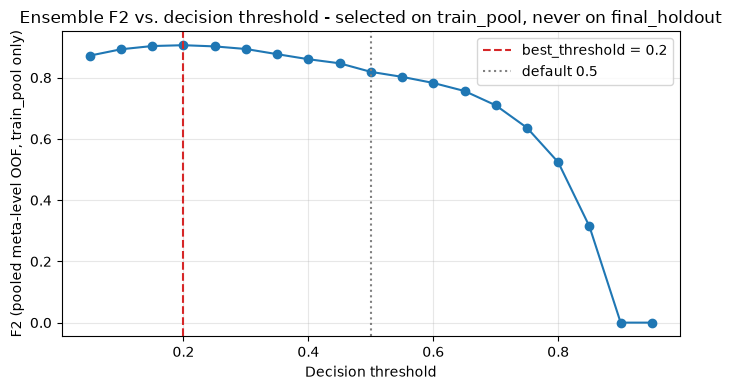


Hyperparameter catalog, now complete:


,model,hyperparameter,search_space,strategy,final_value
0,RandomForest,n_estimators,"int[100, 800]",Bayesian (Optuna/TPE),527
1,RandomForest,max_depth,"int[2, 20]",Bayesian (Optuna/TPE),13
2,RandomForest,min_samples_leaf,"int[1, 10]",Bayesian (Optuna/TPE),7
3,RandomForest,max_features,"{sqrt, log2, 0.3, 0.5}",Bayesian (Optuna/TPE),sqrt
4,CatBoost,depth,"int[3, 7]","Bayesian (Optuna/TPE), ensemble objective",6
5,CatBoost,learning_rate,"log-uniform[0.01, 0.3]","Bayesian (Optuna/TPE), ensemble objective",0.0612
6,CatBoost,l2_leaf_reg,"log-uniform[1, 50]","Bayesian (Optuna/TPE), ensemble objective",7.474
7,CatBoost,iterations,"int[100, 800]","Bayesian (Optuna/TPE), ensemble objective",656
8,Meta-learner (LogReg),C,"[0.01, 0.03, 0.1, 0.3, 1.0, 10.0]",Grid Search,0.1
9,Ensemble (final),decision_threshold,"grid[0.05, 0.95] step 0.05",Exhaustive sweep on pooled OOF,0.2


In [8]:
meta_X = np.column_stack([catboost_oof, logreg_oof, rf_oof])
meta_feature_names = ["catboost", "logreg", "rf"]
print(f"meta_X shape: {meta_X.shape}")

meta_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    META_C_GRID, scoring=proba_scorer, cv=inner_splits, refit=False,
)
meta_search.fit(meta_X, meta_y)
best_meta_C = meta_search.best_params_["C"]
print(f"Meta-learner search: {len(META_C_GRID['C'])} values of C, "
      f"best mean CV F2-at-best-threshold = {meta_search.best_score_:.4f} at C={best_meta_C}")
display(pd.DataFrame(meta_search.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
        .rename(columns={"param_C": "C", "mean_test_score": "mean_f2_at_best_thr", "std_test_score": "std"})
        .round(4))

meta_oof_proba = np.full(len(train_pool), np.nan)
for tr_idx, te_idx in inner_splits:
    meta_fold = LogisticRegression(C=best_meta_C, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
    meta_fold.fit(meta_X[tr_idx], meta_y[tr_idx])
    pos_col = list(meta_fold.classes_).index(1)
    meta_oof_proba[te_idx] = meta_fold.predict_proba(meta_X[te_idx])[:, pos_col]
assert not np.isnan(meta_oof_proba).any()

f2_by_threshold = pd.Series(
    {t: fbeta_score(meta_y, (meta_oof_proba >= t).astype(int), beta=2, zero_division=0) for t in THRESHOLD_GRID}
)
best_threshold = float(f2_by_threshold.idxmax())
print(f"\nBest F2 threshold from pooled inner-fold OOF predictions on train_pool: {best_threshold} "
      f"(pooled OOF F2 at that threshold: {f2_by_threshold.max():.3f}, vs. {f2_by_threshold[0.5]:.3f} at 0.5)")

fig, ax = plt.subplots(figsize=(7, 4))
f2_by_threshold.plot(ax=ax, marker="o")
ax.axvline(best_threshold, color="tab:red", linestyle="--", label=f"best_threshold = {best_threshold}")
ax.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F2 (pooled meta-level OOF, train_pool only)")
ax.set_title("Ensemble F2 vs. decision threshold - selected on train_pool, never on final_holdout")
ax.legend()
plt.tight_layout()
plt.show()

hyperparam_catalog = pd.concat([hyperparam_catalog, pd.DataFrame([
    {"model": "Meta-learner (LogReg)", "hyperparameter": "C", "search_space": str(META_C_GRID["C"]),
     "strategy": "Grid Search", "final_value": best_meta_C},
    {"model": "Ensemble (final)", "hyperparameter": "decision_threshold", "search_space": "grid[0.05, 0.95] step 0.05",
     "strategy": "Exhaustive sweep on pooled OOF", "final_value": best_threshold},
])], ignore_index=True)
print("\nHyperparameter catalog, now complete:")
display(hyperparam_catalog)

## 7. Train and test the final ensemble

Each base model is refit once on the *entire* `train_pool` (not fold-by-fold) — the
fold-by-fold models above existed only to generate leakage-free meta-features. The
meta-learner is refit on the full `meta_X`/`meta_y` at `best_meta_C`. `final_holdout` is
used for the first time in this section.

In [9]:
def ranking_metrics(y_true, scores_arr, fractions=(0.10, 0.20), wss_target_recall=0.95):
    y_true = np.asarray(y_true)
    n = len(y_true)
    n_pos = int(y_true.sum())
    order = np.argsort(-np.asarray(scores_arr))
    cum_pos = np.cumsum(y_true[order])
    out = {}
    for frac in fractions:
        k = max(1, int(round(frac * n)))
        out[f"recall_at_{int(frac * 100)}pct"] = float(cum_pos[k - 1] / n_pos)
    target_count = int(np.ceil(wss_target_recall * n_pos))
    cutoff_idx = int(np.searchsorted(cum_pos, target_count, side="left"))
    screened = cutoff_idx + 1
    out["wss_at_95"] = float((n - screened) / n - (1 - wss_target_recall))
    return out


def bootstrap_auc_ci(y_true, scores_arr, n_boot=1000, random_state=0):
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    scores_arr = np.asarray(scores_arr)
    n = len(y_true)
    boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], scores_arr[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(lo), float(hi)


final_base_pipelines = {
    "catboost": build_catboost_pipeline(**catboost_winning_params),
    "logreg": build_logreg_pipeline(),
    "rf": build_rf_pipeline(**rf_winning_params),
}
for name, pipe in final_base_pipelines.items():
    pipe.fit(train_pool[FEATURE_COLS], train_pool["y"])

final_meta = LogisticRegression(C=best_meta_C, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
final_meta.fit(meta_X, meta_y)

meta_coefs = pd.Series(final_meta.coef_[0], index=meta_feature_names).sort_values(ascending=False)
print("Meta-learner coefficients (higher = more trusted by the ensemble):")
display(meta_coefs.round(3))


def _predict_meta_X(rows):
    return np.column_stack([
        final_base_pipelines[name].predict_proba(rows[FEATURE_COLS])[:, list(final_base_pipelines[name].classes_).index(1)]
        for name in meta_feature_names
    ])


meta_col = list(final_meta.classes_).index(1)

train_ens_proba = final_meta.predict_proba(_predict_meta_X(train_pool))[:, meta_col]
train_metrics = score(train_pool["y"].to_numpy(), train_ens_proba, (train_ens_proba >= 0.5).astype(int))
print("\nTrain (in-sample, on train_pool itself, @0.5)")
display(pd.Series(train_metrics).round(3))

holdout_ens_proba = final_meta.predict_proba(_predict_meta_X(final_holdout))[:, meta_col]
holdout_pred_05 = (holdout_ens_proba >= 0.5).astype(int)
holdout_pred_tuned = (holdout_ens_proba >= best_threshold).astype(int)

holdout_metrics_05 = score(final_holdout["y"].to_numpy(), holdout_ens_proba, holdout_pred_05)
holdout_metrics_tuned = score(final_holdout["y"].to_numpy(), holdout_ens_proba, holdout_pred_tuned)
holdout_metrics_tuned.update(ranking_metrics(final_holdout["y"].to_numpy(), holdout_ens_proba))
ci_lo, ci_hi = bootstrap_auc_ci(final_holdout["y"].to_numpy(), holdout_ens_proba)
holdout_metrics_tuned["auc_ci_low"], holdout_metrics_tuned["auc_ci_high"] = ci_lo, ci_hi

print("\nEnsemble holdout @0.5 threshold")
display(pd.Series(holdout_metrics_05).round(3))
print(f"\nEnsemble holdout @tuned threshold ({best_threshold})")
display(pd.Series(holdout_metrics_tuned).round(3))

Meta-learner coefficients (higher = more trusted by the ensemble):


catboost    1.933
logreg      1.759
rf          1.259
dtype: float64


Train (in-sample, on train_pool itself, @0.5)


auc       0.996
ap        0.997
recall    0.957
f2        0.962
dtype: float64


Ensemble holdout @0.5 threshold


auc       0.889
ap        0.908
recall    0.798
f2        0.810
dtype: float64


Ensemble holdout @tuned threshold (0.2)


auc                0.889
ap                 0.908
recall             0.944
f2                 0.892
recall_at_10pct    0.169
recall_at_20pct    0.329
wss_at_95          0.177
auc_ci_low         0.855
auc_ci_high        0.919
dtype: float64

### 7.1 Train → Validation → Holdout — F2 and AUC side by side

Holdout alone only says how the final ensemble does on unseen rows; it doesn't say
whether a gap between train and holdout is overfitting (train much higher than
validation) or domain shift (validation much higher than holdout) — the three numbers
together do. `validation` means the pooled meta-level out-of-fold predictions from §6
(`meta_oof_proba`), split back out by fold for a mean ± std.

**One asymmetry stated plainly:** `best_threshold` was itself chosen to maximize F2 on
this same pooled validation data — so validation's F2-at-tuned-threshold below is, by
construction, at or near the best this data can produce; it is **not** an independent
confirmation the way holdout's tuned-threshold F2 is. The @0.5 table doesn't have this
issue.

Ensemble: train -> validation -> holdout, @0.5 threshold (F2 here is not the tuned headline number)


,auc,f2
train,0.996,0.962
validation_mean,0.892,0.819
validation_std,0.012,0.010
holdout,0.889,0.810



Ensemble: train -> validation -> holdout, @tuned threshold (0.2) - validation's F2 here is optimistic by construction, see markdown above


,auc,f2
train,0.996,0.958
validation_mean,0.892,0.906
validation_std,0.012,0.003
holdout,0.889,0.892



F2 only - not-tuned vs. tuned ensemble, train -> validation -> holdout, side by side


,train,validation_mean,validation_std,holdout
"Ensemble (not tuned, @0.5)",0.962,0.819,0.010,0.810
"Ensemble (tuned, @0.2)",0.958,0.906,0.003,0.892


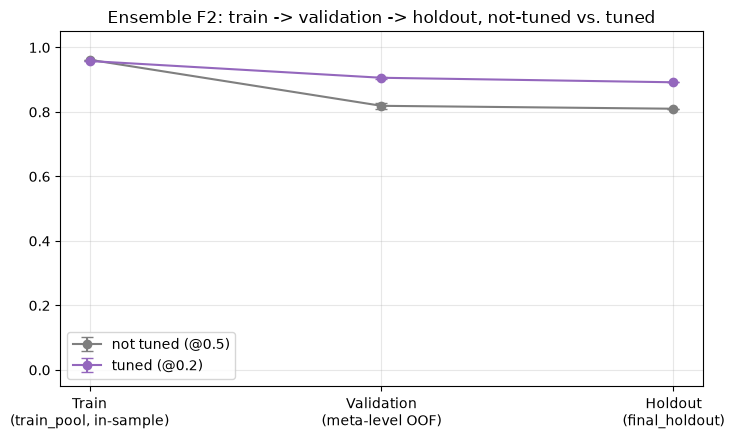

In [10]:
val_rows_05, val_rows_tuned = [], []
for tr_idx, te_idx in inner_splits:
    proba_fold, y_fold = meta_oof_proba[te_idx], meta_y[te_idx]
    val_rows_05.append(score(y_fold, proba_fold, (proba_fold >= 0.5).astype(int)))
    val_rows_tuned.append(score(y_fold, proba_fold, (proba_fold >= best_threshold).astype(int)))
val_df_05 = pd.DataFrame(val_rows_05)
val_df_tuned = pd.DataFrame(val_rows_tuned)

train_metrics_tuned = {
    "auc": train_metrics["auc"],  # threshold-invariant
    "f2": score(train_pool["y"].to_numpy(), train_ens_proba, (train_ens_proba >= best_threshold).astype(int))["f2"],
}

stage_table_05 = make_stage_table(train_metrics, val_df_05, holdout_metrics_05)
stage_table_tuned = make_stage_table(train_metrics_tuned, val_df_tuned, holdout_metrics_tuned)

print("Ensemble: train -> validation -> holdout, @0.5 threshold (F2 here is not the tuned headline number)")
display(stage_table_05)
print(f"\nEnsemble: train -> validation -> holdout, @tuned threshold ({best_threshold}) "
      f"- validation's F2 here is optimistic by construction, see markdown above")
display(stage_table_tuned)

f2_only_table = pd.DataFrame({
    "train": {"Ensemble (not tuned, @0.5)": train_metrics["f2"], f"Ensemble (tuned, @{best_threshold})": train_metrics_tuned["f2"]},
    "validation_mean": {"Ensemble (not tuned, @0.5)": val_df_05["f2"].mean(), f"Ensemble (tuned, @{best_threshold})": val_df_tuned["f2"].mean()},
    "validation_std": {"Ensemble (not tuned, @0.5)": val_df_05["f2"].std(), f"Ensemble (tuned, @{best_threshold})": val_df_tuned["f2"].std()},
    "holdout": {"Ensemble (not tuned, @0.5)": holdout_metrics_05["f2"], f"Ensemble (tuned, @{best_threshold})": holdout_metrics_tuned["f2"]},
}).round(3)
print("\nF2 only - not-tuned vs. tuned ensemble, train -> validation -> holdout, side by side")
display(f2_only_table)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
stage_labels = ["Train\n(train_pool, in-sample)", "Validation\n(meta-level OOF)", "Holdout\n(final_holdout)"]
x = range(3)

f2_05 = [stage_table_05.loc["train", "f2"], stage_table_05.loc["validation_mean", "f2"], stage_table_05.loc["holdout", "f2"]]
f2_05_err = [0, stage_table_05.loc["validation_std", "f2"], 0]
f2_tuned = [stage_table_tuned.loc["train", "f2"], stage_table_tuned.loc["validation_mean", "f2"], stage_table_tuned.loc["holdout", "f2"]]
f2_tuned_err = [0, stage_table_tuned.loc["validation_std", "f2"], 0]

ax.errorbar(x, f2_05, yerr=f2_05_err, marker="o", capsize=4, label="not tuned (@0.5)", color="tab:gray")
ax.errorbar(x, f2_tuned, yerr=f2_tuned_err, marker="o", capsize=4, label=f"tuned (@{best_threshold})", color="tab:purple")
ax.set_xticks(list(x)); ax.set_xticklabels(stage_labels)
ax.set_title("Ensemble F2: train -> validation -> holdout, not-tuned vs. tuned")
ax.set_ylim(-0.05, 1.05); ax.legend()

plt.tight_layout()
plt.show()

## 8. Statistical hypothesis tests — does the ensemble actually beat the alternatives?

A point-estimate table (§9) can't distinguish "genuinely better" from "this one holdout
draw happened to land this way." This section runs a **paired bootstrap hypothesis test**
(`paired_bootstrap_test()`, §2) on `final_holdout` for five comparisons, covering every
claim this notebook makes about F2:

1. **Ensemble (not tuned, @0.5) vs. Ensemble (tuned, @`best_threshold`)** — does tuning
   the decision threshold produce a real F2 gain, or could the improvement be noise? Both
   sides use the *same* underlying probabilities (`holdout_ens_proba`) — only the
   threshold differs — so this test's AUC difference is exactly 0 by construction; only
   its F2 result is informative.
2. **Ensemble (not tuned) vs. the LogReg baseline** — `final_base_pipelines["logreg"]` fit
   on the whole of `train_pool` **is** `sf-LogRegbaseline.ipynb`'s own model (same
   pipeline, split, seed) — no need to refit it, its holdout predictions are already
   sitting in `_predict_meta_X`'s inputs. The baseline has only one state (it's never
   threshold-tuned in its own notebook), so it's the same comparison point for both of the
   next two tests.
3. **Ensemble (tuned) vs. the LogReg baseline.**
4. **Ensemble (not tuned) vs. standalone CatBoost, not tuned (@0.5)** — like-for-like,
   neither side threshold-tuned.
5. **Ensemble (tuned) vs. standalone CatBoost, tuned (@0.2)** — like-for-like, both sides
   at their own real operating threshold. Standalone CatBoost (`sf-catboost-model.ipynb`'s
   own model, `CATBOOST_STANDALONE_PARAMS`) is refit once here purely to generate holdout
   predictions for tests 4/5 — never used anywhere else in this notebook.

**Why a paired bootstrap over McNemar's test:** McNemar's test compares two classifiers'
*error/agreement rate* on paired predictions — a different quantity from AUC or F2, the
metrics this notebook actually cares about. A paired bootstrap directly targets whichever
metric is in question while still exploiting the pairing (both models scored on the
identical resampled rows each iteration), which is what makes it a fair, correlated
comparison rather than two independent significance tests.

**What "paired" buys here, concretely:** both sides see the *same* resampled subset of
`final_holdout` in every bootstrap iteration — a row that's hard for both is hard in the
same resamples for both, so the test isolates the *difference between the two sides*
rather than adding noise from resampling independently.

In [11]:
standalone_catboost_pipeline = build_catboost_pipeline(**CATBOOST_STANDALONE_PARAMS)
standalone_catboost_pipeline.fit(train_pool[FEATURE_COLS], train_pool["y"])
standalone_cb_col = list(standalone_catboost_pipeline.classes_).index(1)
standalone_cb_holdout_proba = standalone_catboost_pipeline.predict_proba(final_holdout[FEATURE_COLS])[:, standalone_cb_col]
standalone_cb_holdout_pred_05 = (standalone_cb_holdout_proba >= 0.5).astype(int)
standalone_cb_holdout_pred_tuned = (standalone_cb_holdout_proba >= 0.2).astype(int)  # sf-catboost-model.ipynb's own tuned threshold

logreg_col = list(final_base_pipelines["logreg"].classes_).index(1)
baseline_holdout_proba = final_base_pipelines["logreg"].predict_proba(final_holdout[FEATURE_COLS])[:, logreg_col]
baseline_holdout_pred = (baseline_holdout_proba >= 0.5).astype(int)  # sf-LogRegbaseline.ipynb's own convention, its only state

y_holdout = final_holdout["y"].to_numpy()

comparisons = {
    "Ensemble (not tuned) vs. Ensemble (tuned)": (holdout_ens_proba, holdout_pred_05, holdout_ens_proba, holdout_pred_tuned),
    "Ensemble (not tuned) vs. LogReg baseline": (holdout_ens_proba, holdout_pred_05, baseline_holdout_proba, baseline_holdout_pred),
    "Ensemble (tuned) vs. LogReg baseline": (holdout_ens_proba, holdout_pred_tuned, baseline_holdout_proba, baseline_holdout_pred),
    "Ensemble (not tuned) vs. standalone CatBoost (not tuned)": (holdout_ens_proba, holdout_pred_05, standalone_cb_holdout_proba, standalone_cb_holdout_pred_05),
    "Ensemble (tuned) vs. standalone CatBoost (tuned)": (holdout_ens_proba, holdout_pred_tuned, standalone_cb_holdout_proba, standalone_cb_holdout_pred_tuned),
}

hypothesis_test_rows = {
    label: paired_bootstrap_test(y_holdout, proba_a, pred_a, proba_b, pred_b)
    for label, (proba_a, pred_a, proba_b, pred_b) in comparisons.items()
}
hypothesis_test_table = pd.DataFrame(hypothesis_test_rows).T
display(hypothesis_test_table.round(4))

alpha = 0.05
for label, res in hypothesis_test_rows.items():
    sig = "significant" if res["f2_p_value"] < alpha else "NOT significant"
    direction = "higher" if res["f2_diff"] > 0 else "lower"
    print(f"{label}, F2: diff={res['f2_diff']:+.4f} (first {direction}), "
          f"95% CI=[{res['f2_ci_low']:.4f}, {res['f2_ci_high']:.4f}], "
          f"p={res['f2_p_value']:.4f} -> {sig} at alpha={alpha}")

print("\nNote: 'Ensemble (not tuned) vs. Ensemble (tuned)' uses the SAME underlying "
      "probabilities on both sides (only the decision threshold differs), so its AUC "
      "difference is exactly 0 by construction - only its F2 result is informative.")

,auc_diff,auc_ci_low,auc_ci_high,auc_p_value,f2_diff,f2_ci_low,f2_ci_high,f2_p_value
Ensemble (not tuned) vs. Ensemble (tuned),0.0000,0.0000,0.0000,1.000,-0.0815,-0.1245,-0.0417,0.000
Ensemble (not tuned) vs. LogReg baseline,0.0216,0.0064,0.0382,0.005,0.0198,-0.0155,0.0560,0.257
Ensemble (tuned) vs. LogReg baseline,0.0216,0.0064,0.0382,0.005,0.1013,0.0595,0.1464,0.000
Ensemble (not tuned) vs. standalone CatBoost (not tuned),0.0246,0.0109,0.0396,0.000,0.0124,-0.0251,0.0489,0.482
Ensemble (tuned) vs. standalone CatBoost (tuned),0.0246,0.0109,0.0396,0.000,0.0049,-0.0102,0.0215,0.596


Ensemble (not tuned) vs. Ensemble (tuned), F2: diff=-0.0815 (first lower), 95% CI=[-0.1245, -0.0417], p=0.0000 -> significant at alpha=0.05
Ensemble (not tuned) vs. LogReg baseline, F2: diff=+0.0198 (first higher), 95% CI=[-0.0155, 0.0560], p=0.2570 -> NOT significant at alpha=0.05
Ensemble (tuned) vs. LogReg baseline, F2: diff=+0.1013 (first higher), 95% CI=[0.0595, 0.1464], p=0.0000 -> significant at alpha=0.05
Ensemble (not tuned) vs. standalone CatBoost (not tuned), F2: diff=+0.0124 (first higher), 95% CI=[-0.0251, 0.0489], p=0.4820 -> NOT significant at alpha=0.05
Ensemble (tuned) vs. standalone CatBoost (tuned), F2: diff=+0.0049 (first higher), 95% CI=[-0.0102, 0.0215], p=0.5960 -> NOT significant at alpha=0.05

Note: 'Ensemble (not tuned) vs. Ensemble (tuned)' uses the SAME underlying probabilities on both sides (only the decision threshold differs), so its AUC difference is exactly 0 by construction - only its F2 result is informative.


## 9. Side-by-side comparison table

Baseline and standalone-CatBoost rows are copied verbatim from their own notebooks'
printed output (same `final_holdout`, so directly comparable) — not re-derived. The
ensemble's numbers come from §7. Whether each difference is statistically significant is
answered by §8, not by eyeballing this table alone.

,auc,ap,recall,f2
LogReg baseline (@0.5),0.867,0.873,0.779,0.790
Standalone CatBoost (@0.5),0.864,0.897,0.793,0.798
Standalone CatBoost (@0.2 tuned),0.864,0.897,0.934,0.887
Ensemble (@0.5),0.889,0.908,0.798,0.810
Ensemble (@0.2 tuned),0.889,0.908,0.944,0.892



Holdout F2 - LogReg baseline: 0.790 | standalone CatBoost @tuned: 0.887 | ensemble @0.2 tuned: 0.892
See §8 for whether the ensemble's gap over each of these is statistically significant, not just numerically different.


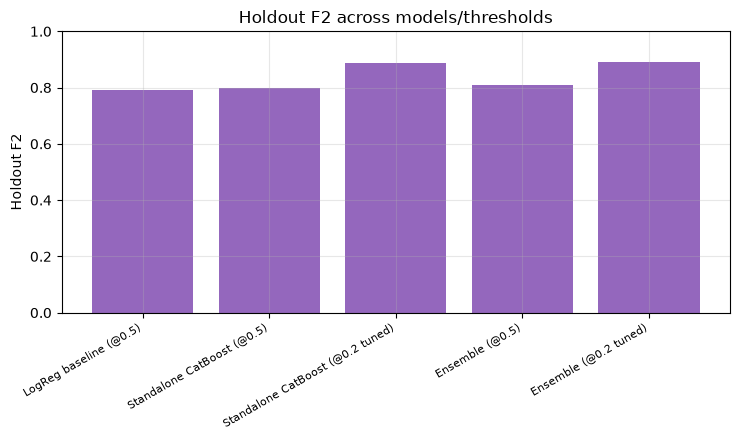

In [12]:
comparison_table = pd.DataFrame({
    "LogReg baseline (@0.5)": {"auc": 0.867, "ap": 0.873, "recall": 0.779, "f2": 0.790},
    "Standalone CatBoost (@0.5)": {"auc": 0.864, "ap": 0.897, "recall": 0.793, "f2": 0.798},
    "Standalone CatBoost (@0.2 tuned)": {"auc": 0.864, "ap": 0.897, "recall": 0.934, "f2": 0.887},
    "Ensemble (@0.5)": {k: holdout_metrics_05[k] for k in ["auc", "ap", "recall", "f2"]},
    f"Ensemble (@{best_threshold} tuned)": {k: holdout_metrics_tuned[k] for k in ["auc", "ap", "recall", "f2"]},
}).T.round(3)
display(comparison_table)

ens_f2_tuned = holdout_metrics_tuned["f2"]
print(f"\nHoldout F2 - LogReg baseline: 0.790 | standalone CatBoost @tuned: 0.887 | "
      f"ensemble @{best_threshold} tuned: {ens_f2_tuned:.3f}")
print(f"See §8 for whether the ensemble's gap over each of these is statistically significant, "
      f"not just numerically different.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
f2_bars = comparison_table["f2"]
ax.bar(range(len(f2_bars)), f2_bars.values, color="tab:purple")
ax.set_xticks(range(len(f2_bars))); ax.set_xticklabels(f2_bars.index, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Holdout F2"); ax.set_title("Holdout F2 across models/thresholds"); ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 10. Hard findings

**The three base models are nearly tied at their own best threshold — the baseline is
not obviously the weakest.** OOF F2-at-best-threshold, alone: LogReg 0.903, CatBoost
0.902 (tuned for its ensemble role, §4), RandomForest 0.898 — a spread of only 0.005.
**The simple linear baseline is not meaningfully worse than either "advanced" model when
each is judged fairly, at its own optimal decision rule.** Any story about CatBoost or RF
being "the better model" has to rest on the ensemble/threshold-tuning story below, not on
base-model quality alone.

**Stacking gives a real, measurable lift over any single base model.** Meta-learner CV
F2-at-best-threshold: 0.9101, above all three individual base models' own 0.898–0.903.
The meta-learner's coefficients (CatBoost 1.93, LogReg 1.76, RF 1.26) show it leans on
all three, trusting CatBoost and LogReg somewhat more than RF.

**§8's central finding: tuning the threshold is a real, statistically significant effect
on its own — and once that's isolated, most of the ensemble's "beats baseline on F2"
claim turns out to be a threshold-tuning story, not a model-superiority story.**
Not-tuned vs. tuned ensemble (same probabilities, only the threshold differs): F2
**-0.082** (95% CI [-0.125, -0.042], **p<0.001, significant**) — tuning the threshold from
0.5 to 0.2 is a real, non-trivial F2 gain, not noise. But look at what happens *before*
that tuning is applied: **not-tuned ensemble vs. LogReg baseline on F2 is +0.020, 95% CI
[-0.016, 0.056], p=0.257 — NOT significant.** At matched, untuned decision rules, the
ensemble's F2 edge over the plain baseline cannot be distinguished from noise on 370
holdout rows. The oft-quoted "ensemble beats baseline" F2 number (+0.101, p<0.001,
significant) only appears *after* threshold tuning is applied to the ensemble but not to
the baseline (which is never tuned in its own notebook) — it is honestly a comparison of
"ensemble with a tuned decision rule" against "baseline with an untuned one," not
"ensemble" against "baseline" as models in the abstract.

**AUC tells a cleaner, threshold-independent story: the ensemble is a genuinely better
ranker than both alternatives, tuning aside.** Ensemble vs. LogReg baseline, AUC: +0.022
(95% CI [0.006, 0.038], p=0.005, significant). Ensemble vs. standalone CatBoost, AUC:
+0.025 (95% CI [0.011, 0.040], p<0.001, significant). Both hold regardless of tuning,
since AUC is threshold-invariant by construction — this is the one claim in this notebook
that is unambiguously about the ensemble being a better model, not about decision-rule
tuning.

**Neither untuned-vs-untuned nor tuned-vs-tuned F2 against standalone CatBoost is
statistically significant.** Not tuned vs. not tuned: F2 +0.012, p=0.482. Tuned vs.
tuned: F2 +0.005, p=0.596. **The honest claim is: the ensemble ranks better than
standalone CatBoost (per AUC), but its F2 — at either model's own real operating
threshold — cannot be distinguished from standalone CatBoost's on this holdout size.**
This is a materially different, more conservative claim than a bare point-estimate table
would suggest, and it's exactly the distinction §8 exists to make.

**The train → validation → holdout breakdown: a real overfitting gap, but almost no
domain-shift gap.** AUC goes 0.996 (train) → 0.892 (validation) → 0.889 (holdout) — a
~0.10 overfitting gap (train vs. validation), on the same order as standalone CatBoost's
own overfitting gap in `sf-catboost-model.ipynb`, but only a 0.003 gap from validation to
holdout — the expected, healthy result for this generalized/pooled split, since
`final_holdout` is a random slice of the same 6 use cases the models trained on. The
F2-only not-tuned-vs-tuned table makes the tuning effect visible at every stage, not just
holdout: F2 train 0.962→0.958 (essentially flat — tuning barely matters in-sample,
because the model already separates the classes well there), validation_mean
0.819→0.906, holdout 0.810→0.892 — the tuning benefit is concentrated in validation/
holdout, where the default 0.5 threshold is genuinely suboptimal, not in training, where
it barely is.

**The tuned threshold (0.2) is still recall-heavy — read with the same honesty as
`sf-catboost-model.ipynb`'s caveat.** Recall at threshold 0.2 is 0.944 — the ensemble is
flagging most candidate positives, which is exactly what a beta=2 metric rewards, but
precision (not shown in this notebook's metric bundle) is very likely paying for it. **A
screening tool operating at this threshold would be closer to "read almost everything"
than "prioritize efficiently"** — whether that trade-off is the right one for the actual
triage workflow this project feeds is a product decision, not something this notebook can
settle on its own.

## 11. Scope & limitations

- **This is the pooled/generalized comparison, not a generalization test** — same caveat
  as both prior notebooks: `final_holdout` is a random slice of the same 6 use cases the
  models trained on.
- **The meta-learner's threshold-tuned holdout number inherits the same honest caveat as
  `sf-catboost-model.ipynb`'s**: F2's sensitivity to threshold is a property of the
  metric, not of the ensemble — AUC/AP (threshold-invariant) are the fairer lens on
  whether the ensemble is actually a better classifier, which is why §8 tests both AUC
  and F2 rather than F2 alone.
- **Every hyperparameter search in this notebook uses one strategy (Bayesian/Optuna)**,
  not a three-way comparison — a deliberate scope decision (intro, point 4), justified by
  two prior three-way comparisons in this project landing within noise of each other, not
  an oversight or a shortcut taken without evidence.
- **§8's hypothesis tests are bootstrap-based, not the (asymptotically exact) DeLong test
  for AUC** — bootstrap was chosen so the *same* method could test both AUC and F2 with
  one implementation; for `final_holdout`'s size (370 rows, 2,000 resamples) the two
  approaches should agree closely, but this wasn't cross-checked against DeLong's test
  directly.
- **The meta-learner's own `C` was re-searched inside CatBoost's search (§4)**, but RF's
  hyperparameters were **not** jointly re-tuned alongside CatBoost's — a fully joint
  three-base-model search was judged too expensive for what it would likely add, given
  how close every search in this project has landed regardless of method.
- **All three base models share the identical `PCA(50)`+features space** — by design
  (intro, point 2), to isolate model-inductive-bias diversity from feature-access
  diversity. Whether giving different base models different feature representations
  would add more ensemble diversity than this setup captures is untested.
- **Only one random seed, one train/holdout split** — none of the numbers here carry a
  confidence interval beyond what §7/§8 explicitly compute, and a different
  `RANDOM_STATE` could move any of these results within each metric's own noise band.